In [8]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
import matplotlib.pyplot as plt
import os
import numpy as np
import nglview as nv
from simple_mda import *
import pickle
from scipy.stats import gaussian_kde

In [9]:
WT_r1 = mda.Universe("data/WT_r1.tpr", "data/WT_r1.xtc")
D166N_r1 = mda.Universe("data/D166N_r1.tpr", "data/D166N_r1.xtc")
WT_r2 = mda.Universe("data/WT_r2.tpr", "data/WT_r2.xtc")
D166N_r2 = mda.Universe("data/D166N_r2.tpr", "data/D166N_r2.xtc")
WT_r3 = mda.Universe("data/WT_r3.tpr", "data/WT_r3.xtc")
D166N_r3 = mda.Universe("data/D166N_r3.tpr", "data/D166N_r3.xtc")

In [10]:
def load_distance_data(pkl_file):
    with open(pkl_file, "rb") as f:
        return pickle.load(f)

def find_frames_near_distance(universes, dist_data, system, chain_pair, target_dist, n=3, tolerance=0.5):
    """Find n frames where the distance is close to target_dist."""
    
    # Get distances for this system/chain pair across all repeats
    pair_distances = dist_data[system][chain_pair]  # list of 3 arrays (one per repeat)
    
    # Build frame index and collect distances
    frame_index = []
    all_distances = []
    
    for repeat_idx, (u, distances) in enumerate(zip(universes[system], pair_distances)):
        for frame_idx, dist in enumerate(distances):
            frame_index.append((u, frame_idx))
            all_distances.append(dist)
    
    all_distances = np.array(all_distances)
    
    # Find frames closest to target distance
    diff = np.abs(all_distances - target_dist)
    closest = np.argsort(diff)[:n]
    
    return [(frame_index[i], all_distances[i]) for i in closest]

def save_frames_near_distance(universes, dist_data, system, chain_pair, target_dist, 
                               chain_length=408, start_resid=120, n=3):
    """Save n frames near target distance as PDB."""
    
    frames = find_frames_near_distance(universes, dist_data, system, chain_pair, target_dist, n=n)
    
    for i, ((u, frame), dist) in enumerate(frames):
        u.trajectory[frame]
        add_chain_ids(u, chain_length=chain_length, start_resid=start_resid)
        outname = f"{system}_{chain_pair}_dist{target_dist:.1f}_{i}.pdb"
        u.select_atoms("protein").write(outname)
        print(f"Saved {outname}: frame {frame}, distance = {dist:.2f}")



In [11]:
def add_chain_ids(u, chain_length, start_resid=1):
    """Add chain IDs and renumber residues."""
    u.add_TopologyAttr("chainIDs", np.array([""] * len(u.atoms), dtype=object))
    protein = u.select_atoms("protein")
    n_residues = len(protein.residues)
    n_chains = n_residues // chain_length

    for i in range(n_chains):
        chain_id = chr(65 + i)
        start = i * chain_length
        end = min((i + 1) * chain_length, n_residues)
        chain_residues = protein.residues[start:end]
        chain_residues.atoms.chainIDs = chain_id
        # Renumber residues
        for j, res in enumerate(chain_residues):
            res.resid = start_resid + j



In [12]:
universes = {
    "WT":    [WT_r1, WT_r2, WT_r3],
    "D166N": [D166N_r1, D166N_r2, D166N_r3]
}
# Example usage
dist_data = load_distance_data("results/WT_Q134_dist.pkl")
save_frames_near_distance(universes, dist_data, system="WT", chain_pair="AD", target_dist=12)

/home/zengk/miniforge3/envs/biol0041/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/home/zengk/miniforge3/envs/biol0041/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/home/zengk/miniforge3/envs/biol0041/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn(
/home/zengk/miniforge3/envs/biol0041/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn(
/home/zengk/miniforge3/envs/biol0041/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'record_types' Using default value of 'ATOM

Saved WT_AD_dist12.0_0.pdb: frame 639, distance = 12.00
Saved WT_AD_dist12.0_1.pdb: frame 976, distance = 12.00


TypeError: Cannot compare structured arrays unless they have a common dtype.  I.e. `np.result_type(arr1, arr2)` must be defined.

In [13]:
def plot_distance_over_time(dist_data, system, chain_pair):
    fig, ax = plt.subplots()
    
    for repeat_idx, distances in enumerate(dist_data[system][chain_pair]):
        ax.plot(distances, label=f"r{repeat_idx+1}", alpha=0.7)
    
    ax.set_xlabel("Frame")
    ax.set_ylabel("Distance (Å)")
    ax.set_title(f"{system} {chain_pair}")
    ax.set_ylim((0,15))
    ax.legend()
    plt.tight_layout()
    plt.show()


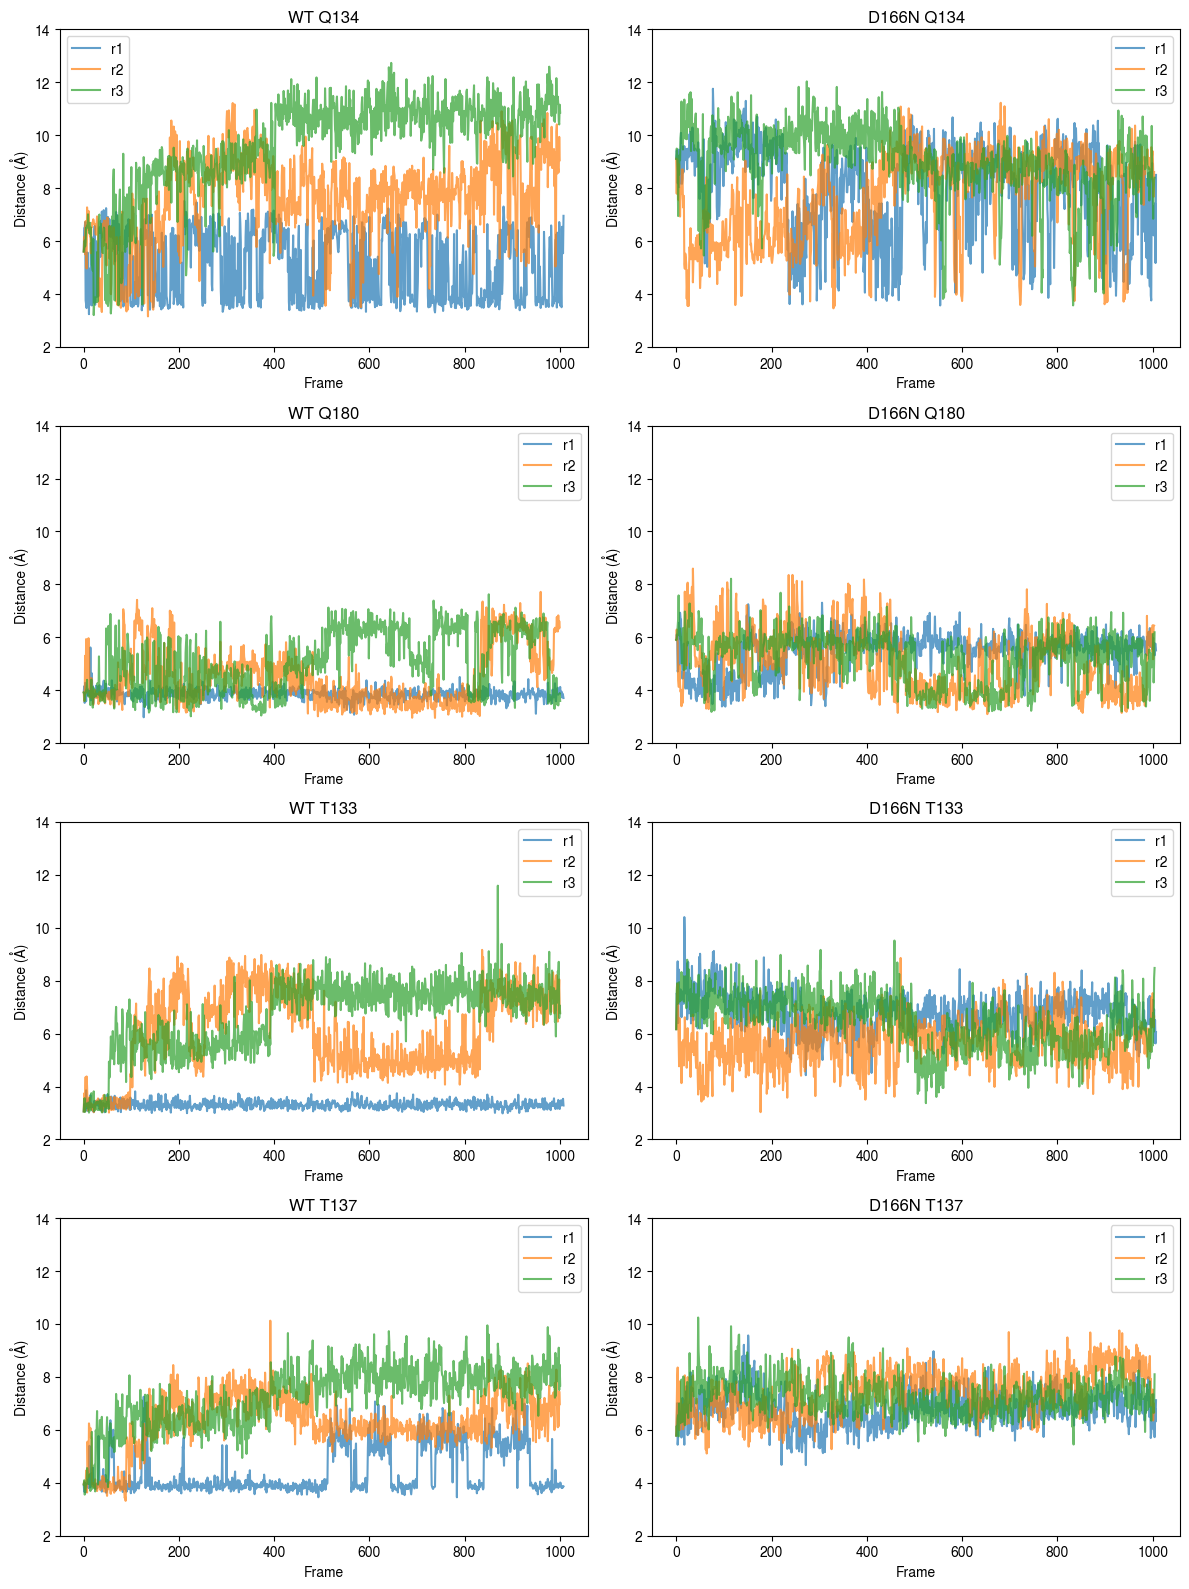

In [14]:
import pickle

residues = ["Q134", "Q180", "T133", "T137"]
systems = ["WT", "D166N"]
chain_pair = "AD"  # change as needed

def load_distance_data(pkl_file):
    with open(pkl_file, "rb") as f:
        return pickle.load(f)

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for row, residue in enumerate(residues):
    for col, system in enumerate(systems):
        ax = axes[row, col]
        dist_data = load_distance_data(f"results/{system}_{residue}_dist.pkl")
        
        for repeat_idx, distances in enumerate(dist_data[system][chain_pair]):
            ax.plot(distances, label=f"r{repeat_idx+1}", alpha=0.7)
        
        ax.set_xlabel("Frame")
        ax.set_ylabel("Distance (Å)")
        ax.set_title(f"{system} {residue}")
        ax.set_ylim((2,14))
        ax.legend()

plt.tight_layout()
plt.show()

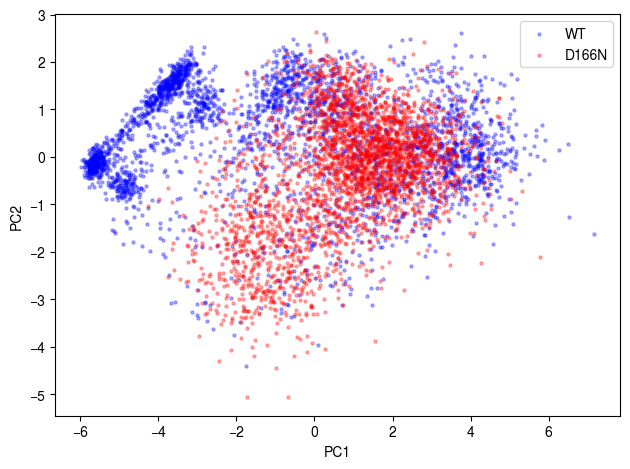

In [15]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


residues = ["Q134", "Q180", "T133", "T137"]
chain_pair = "AD"

# Load all distance data
dist_data = {residue: {system: load_distance_data(f"results/{system}_{residue}_dist.pkl")
                        for system in ["WT", "D166N"]}
             for residue in residues}

def get_distance_coords(dist_data, residues, systems, chain_pair):
    """Concatenate 4 distances into feature vectors across all systems and repeats."""
    all_coords = []
    
    for system in systems:
        for repeat_idx in range(3):
            distances = [dist_data[residue][system][system][chain_pair][repeat_idx] 
                         for residue in residues]
            # distances is a list of 4 arrays, each of length n_frames
            # stack into (n_frames, 4) array
            distances = np.array(distances).T
            all_coords.append(distances)
    
    return np.vstack(all_coords)  # shape: (total_frames, 4)




def get_all_ca_coords(universes, selection, reference=None):
    all_coords = []

    if reference is None:
        first_u = list(universes.values())[0][0]
        reference = mda.Universe(first_u.filename)

    for system, universe_list in universes.items():
        for u in universe_list:
            align.AlignTraj(u, reference, select=selection, in_memory=True).run()
            ca = u.select_atoms(selection)
            for ts in u.trajectory:
                all_coords.append(ca.positions.copy().flatten())

    return np.array(all_coords)


def run_pca(coords, n_components=2):
    pca = PCA(n_components=n_components)
    projected = pca.fit_transform(coords)
    return pca, projected

coords = get_distance_coords(dist_data, residues, ["WT", "D166N"], chain_pair)
pca, projected = run_pca(coords)

# Plot coloured by system
labels = []
for system in ["WT", "D166N"]:
    for repeat_idx, u in enumerate(universes[system]):
        n_frames = len(u.trajectory)
        labels.extend([system] * n_frames)
labels = np.array(labels)

system_colors = {"WT": "blue", "D166N": "red"}

fig, ax = plt.subplots()
for system in ["WT", "D166N"]:
    mask = labels == system
    ax.scatter(projected[mask, 0], projected[mask, 1],
               color=system_colors[system], label=system, alpha=0.3, s=5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
from scipy import stats


def build_distance_dataframe(dist_data, residues, systems, chain_pair):
    """Build a dataframe with one column per residue distance."""
    rows = []
    for system in systems:
        for repeat_idx in range(3):
            distances = [dist_data[residue][system][system][chain_pair][repeat_idx]
                         for residue in residues]
            distances = np.array(distances).T  # (n_frames, 4)
            for frame in distances:
                rows.append(dict(zip(residues, frame), system=system, repeat=f"r{repeat_idx+1}"))
    return pd.DataFrame(rows)

df = build_distance_dataframe(dist_data, residues, ["WT", "D166N"], chain_pair)

for system in ["WT", "D166N"]:
    print(f"\n{system}")
    print(f"{'Pair':<20} {'r':>8} {'p':>12}")
    print("-" * 42)
    sub = df[df["system"] == system]
    for i, res1 in enumerate(residues):
        for res2 in residues[i+1:]:
            r, p = stats.pearsonr(sub[res1], sub[res2])
            print(f"{res1}-{res2:<15} {r:>8.3f} {p:>12.2e}")



WT
Pair                        r            p
------------------------------------------
Q134-Q180               0.502    6.90e-192
Q134-T133               0.789     0.00e+00
Q134-T137               0.785     0.00e+00
Q180-T133               0.650     0.00e+00
Q180-T137               0.573    2.23e-262
T133-T137               0.860     0.00e+00

D166N
Pair                        r            p
------------------------------------------
Q134-Q180              -0.125     5.19e-12
Q134-T133               0.338     1.27e-81
Q134-T137               0.256     2.26e-46
Q180-T133               0.261     2.75e-48
Q180-T137              -0.049     6.92e-03
T133-T137               0.116     1.63e-10


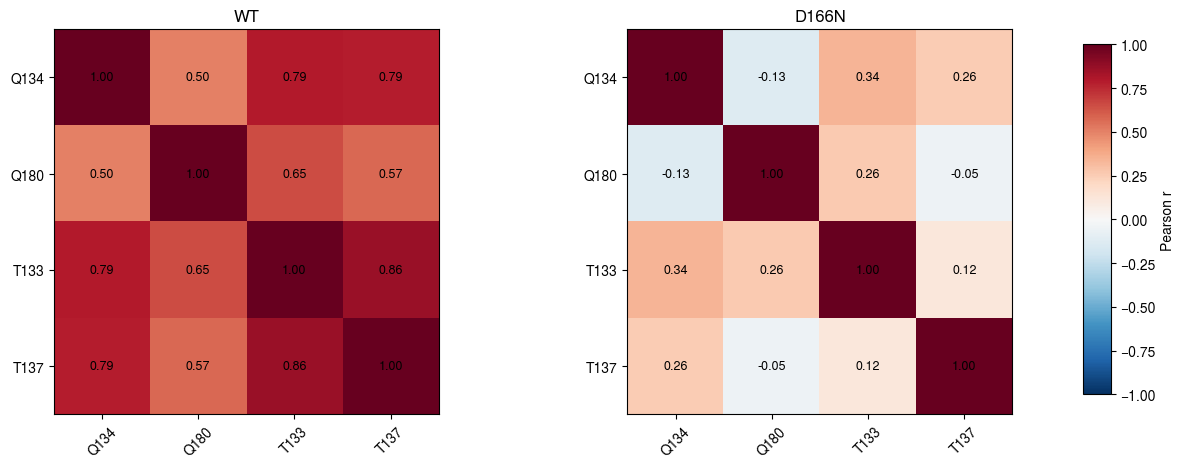

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.subplots_adjust(right=0.85, wspace=0.3)

for ax, system in zip(axes, ["WT", "D166N"]):
    sub = df[df["system"] == system]
    corr = sub[residues].corr()
    
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(residues)))
    ax.set_yticks(range(len(residues)))
    ax.set_xticklabels(residues, rotation=45)
    ax.set_yticklabels(residues)
    ax.set_title(system)
    
    for i in range(len(residues)):
        for j in range(len(residues)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Pearson r")
plt.show()